# Building an Interactive Dashboard for Community Development Planning - Topic 6

### Task 1:  Summary
This dataset highlights how educational attainment intersects with socioeconomic conditions and civic engagement across U.S. counties.  It is built for community leaders, planners, and nonprofit partners who need an interactive way to see how education levels correlate with income, unemployment, and voting patterns for critical signals for equitable investment and social well-being.  The dashboards' prompts can help stakeholders explore which counties face educational challenges, how those challenges relate to economic opportunity and participation, and where targeted support could create the most impact.  Interactivity is vital because users can filter by region, demographic group, and key outcome to uncover patterns that static charts hide.  Ultimately, the outcome equips decision-makers with insights that strengthen stewardship, promote opportunity, and inform data-driven community plannings.

**URL:** https://www.kaggle.com/datasets/adamcuculich/county-socioeconomic-education-and-voting-data/data

### **Data Description:**

The dataset has 10 variables, providing an overview of county-level socioeconomic indicators, educational attainment, and voting outcomes in the United States.


* **State** - U.S. state where the county is located
* **County Name** - Name of county
* **FIPS** - Federal Information Processing Standards county code
* **Unemployment Rate 2020** - County unemployment rate for 2020
* **County Median Household Income (2021)** - Median household income in 2021
* **Urban Influence Code 2013** - Metro/non-metro classification based on urban influence
* **County Income Percentile Within State (2021)** - Percentile ranking of county income within its state
* **Bachelor's Degree or Higher Percentage (2018-2022)** - % of adults (25+) with bachelor's degree or higher
* **Party** - Political party receiving vote percentage
* **Vote Percentage** - % of total votes received by listed party


**URL:** https://www.kaggle.com/datasets/adamcuculich/county-socioeconomic-education-and-voting-data/data


## Import Libraries


In [72]:
# Installing the libraries with the specified version.
!pip install numpy>=2.3 pandas==2.2.2 matplotlib==3.8.4 seaborn==0.13.2 streamlit -q --user

In [112]:
import pandas as pd
import numpy as np

# For visualizing data
import matplotlib.pyplot as plt
import seaborn as sns

# Dashbaords
import plotly.express as px
import plotly.graph_objects as go
#import streamlit as st

# Analytics
import statsmodels

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [119]:
import sys
sys.executable

'/usr/bin/python3'

## Load and explore the data

In [114]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [118]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/MyDrive/11 DSC-525/Topic 6/socioeconomic_voting.csv')

In [116]:
# Loading the dataset


from google.colab import files


uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

Saving socioeconomic_voting.csv to socioeconomic_voting (2).csv


In [78]:
# Copy the data to another variable to avoid any changes to original data
data = df.copy()

In [79]:
# Check the first 5 rows of the data
df.head()

,State,County Name,FIPS,Unemployment Rate 2020,County Median Household Income (2021),Urban Influence Code 2013,County Income Percentile Within State (2021),Bachelor's Degree or Higher Percentage (2018-2022),Party,Vote Percentage
0,ALABAMA,AUTAUGA,1001,5.3,66444.0,2.0,0.955224,29.6,REPUBLICAN,71.436802
1,ALABAMA,BALDWIN,1003,6.1,65658.0,2.0,0.940299,32.6,REPUBLICAN,76.171373
2,ALABAMA,BARBOUR,1005,7.7,38649.0,6.0,0.164179,11.9,REPUBLICAN,53.451226
3,ALABAMA,BIBB,1007,7.3,48454.0,1.0,0.611940,10.9,REPUBLICAN,78.426264
4,ALABAMA,BLOUNT,1009,4.5,56894.0,1.0,0.895522,14.7,REPUBLICAN,89.571553


In [80]:
# Check the last 5 rows of the data
df.tail()

,State,County Name,FIPS,Unemployment Rate 2020,County Median Household Income (2021),Urban Influence Code 2013,County Income Percentile Within State (2021),Bachelor's Degree or Higher Percentage (2018-2022),Party,Vote Percentage
3110,WYOMING,SWEETWATER,56037,7.5,74677.0,8.0,0.826087,20.0,REPUBLICAN,73.236316
3111,WYOMING,TETON,56039,6.0,102709.0,8.0,1.000000,60.3,DEMOCRAT,66.599040
3112,WYOMING,UINTA,56041,6.4,70162.0,8.0,0.739130,19.1,REPUBLICAN,79.247278
3113,WYOMING,WASHAKIE,56043,5.3,62176.0,11.0,0.391304,21.1,REPUBLICAN,80.481151
3114,WYOMING,WESTON,56045,3.9,62509.0,9.0,0.434783,17.6,REPUBLICAN,87.275281


In [81]:
# Check the shape and print the results
print(f"There are {len(data.axes[0])} rows and {len(data.axes[1])} columns.")

There are 3115 rows and 10 columns.


In [82]:
# Check column types and number of values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 10 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   State                                               3115 non-null   object 
 1   County Name                                         3115 non-null   object 
 2   FIPS                                                3115 non-null   int64  
 3   Unemployment Rate 2020                              3115 non-null   float64
 4   County Median Household Income (2021)               3115 non-null   float64
 5   Urban Influence Code 2013                           3115 non-null   float64
 6   County Income Percentile Within State (2021)        3115 non-null   float64
 7   Bachelor's Degree or Higher Percentage (2018-2022)  3115 non-null   float64
 8   Party                                               3115 non-null   object 
 9

* There are 7 numerical columns and 3 categorical columns.

In [83]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

* There are no duplicates.

In [84]:
# Check for NULLs
df.isnull().sum()

,0
State,0
County Name,0
FIPS,0
Unemployment Rate 2020,0
County Median Household Income (2021),0
Urban Influence Code 2013,0
County Income Percentile Within State (2021),0
Bachelor's Degree or Higher Percentage (2018-2022),0
Party,0
Vote Percentage,0


* There are no NULLs.

In [85]:
# Check the statistical summary of the data
df.describe()

,FIPS,Unemployment Rate 2020,County Median Household Income (2021),Urban Influence Code 2013,County Income Percentile Within State (2021),Bachelor's Degree or Higher Percentage (2018-2022),Vote Percentage
count,3115.000000,3115.000000,3115.000000,3115.000000,3115.000000,3115.000000,3115.000000
mean,30624.118780,6.729727,58852.584912,5.227287,0.508261,23.492970,63.351835
std,15003.754786,2.271373,15249.035244,3.475443,0.288880,10.072071,15.663261
min,1001.000000,1.600000,25653.000000,1.000000,0.003937,0.000000,19.649967
25%,19034.000000,5.200000,48972.000000,2.000000,0.257963,16.500000,52.987445
50%,29205.000000,6.600000,56567.000000,5.000000,0.507463,20.900000,65.133424
75%,46004.000000,8.000000,65536.500000,8.000000,0.758621,27.900000,75.898047
max,56045.000000,22.600000,153716.000000,12.000000,1.000000,78.900000,96.181818


* Here is the summary for the seven numerical columns.

In [86]:
# Check the stastoca; summary for the categorical columns
df.describe(include="object")

,State,County Name,Party
count,3115,3115,3115
unique,51,1825,2
top,TEXAS,WASHINGTON,REPUBLICAN
freq,254,31,2569


* Here is the summary for the three categorical columns.

### Univariate Analysis

In [87]:
def histogram_boxplot(df, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=df, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=df, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        df[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        df[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [88]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

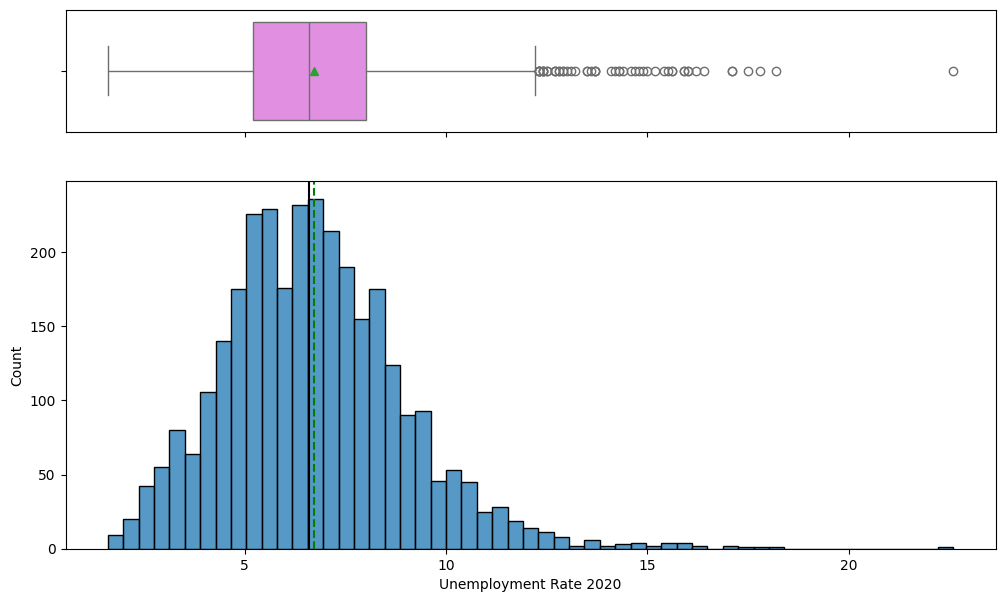

In [36]:
# Create historgram boxplot for Open
histogram_boxplot(df, 'Unemployment Rate 2020')

* The Unemployment Rate 2020 has normal distribution with outliers.
* The mean and median are close.

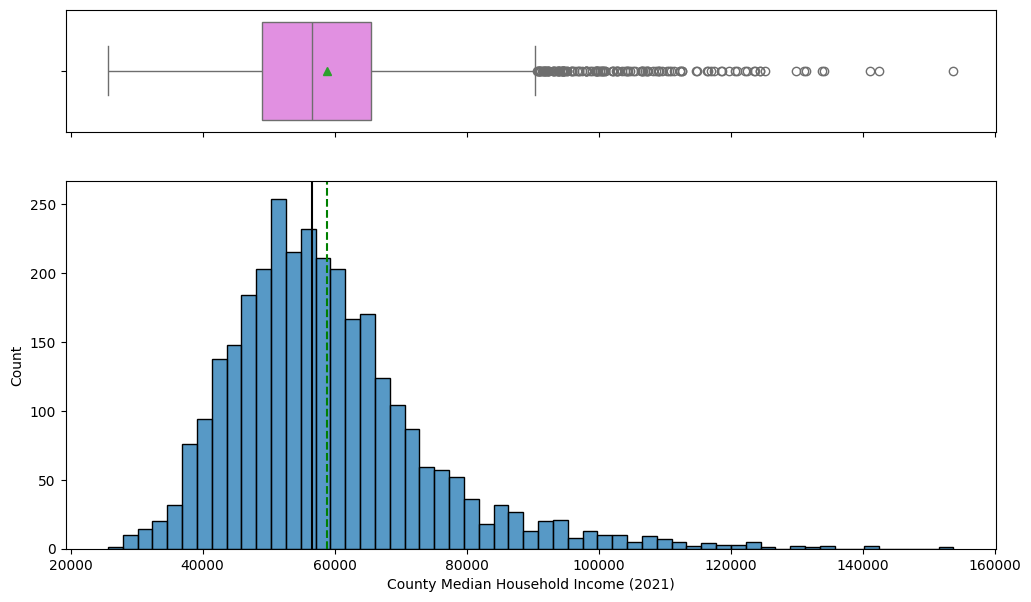

In [37]:
# Create historgram boxplot for High
histogram_boxplot(df, 'County Median Household Income (2021)')

* The County Median Household Income (2021) has a normal distribution with outliers.
* The mean and median are close.

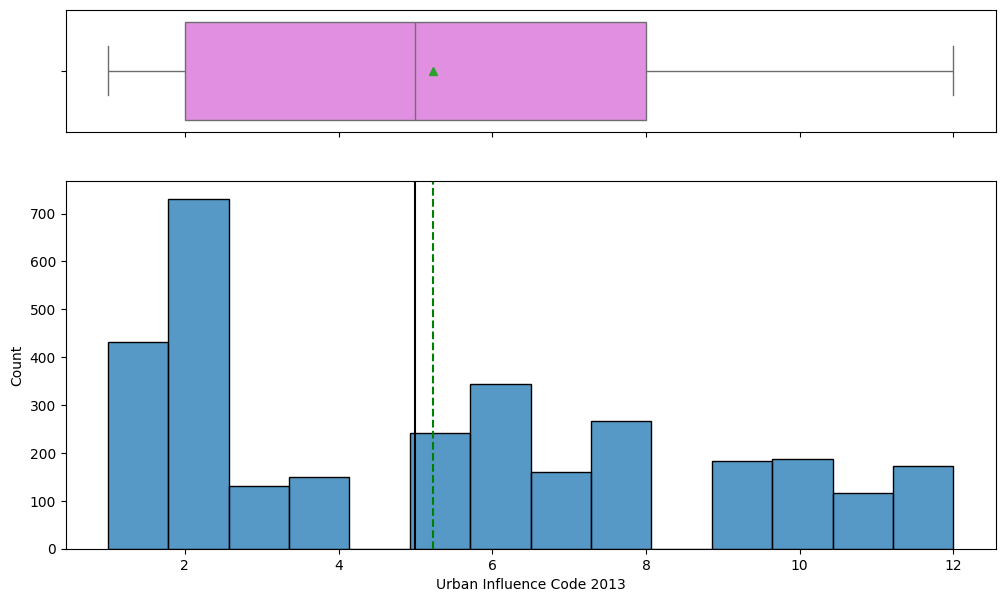

In [38]:
# Create historgram boxplot for Low
histogram_boxplot(df, 'Urban Influence Code 2013')

* The Urban Influence Code 2013 has varying segmentations.
* The mean and median are close.

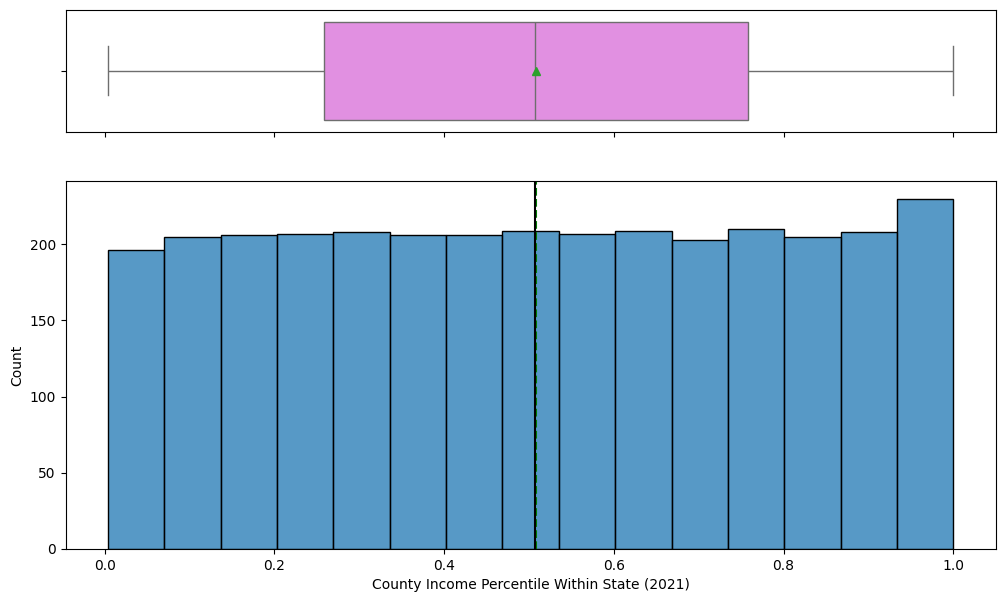

In [39]:
# Create historgram boxplot for Close
histogram_boxplot(df, 'County Income Percentile Within State (2021)')

* The County Income Percentile Within State (2021) is stable with the highest point at ~95%.
* The mean and median are the same at ~50%.

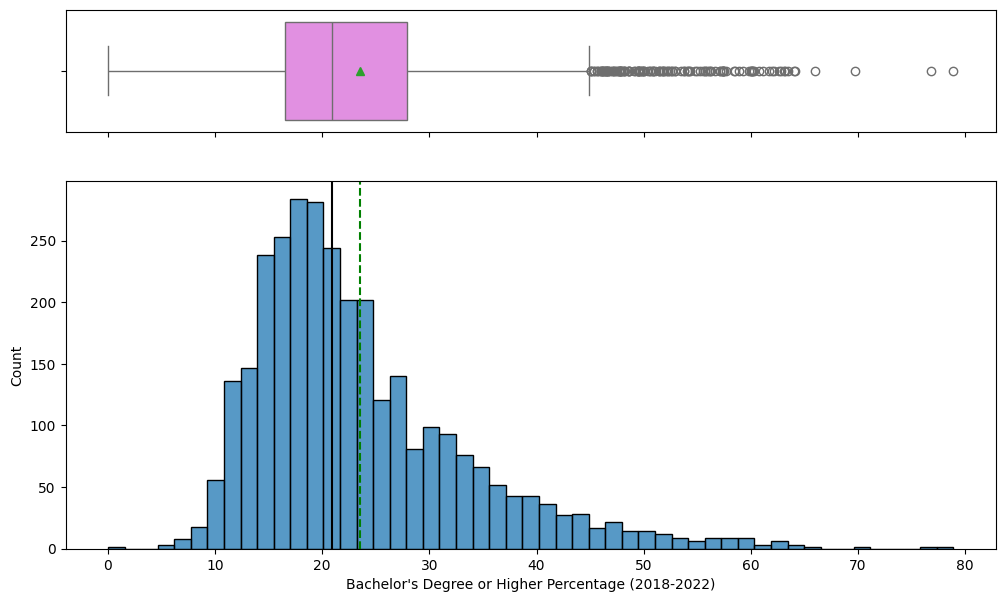

In [41]:
# Create historgram boxplot for Volume
histogram_boxplot(df, "Bachelor's Degree or Higher Percentage (2018-2022)")

* The Bachelor's Degree or Higher Percentage (2018-2022) has a right skew with outliers.
* The mean and median are close.

## Bivariate Analysis

In [110]:
# Create barplot for Bachelor's Degree or Higher Percentage (2018-2022) and State
df = data.copy()
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
state_col = "State"

# Aggregate to state level (mean)
state_avg = (
    df.groupby(state_col)[education_col]
    .mean()
    .reset_index()
    .sort_values(by=education_col, ascending=False)
)

# Create horizontal bar chart
fig = px.bar(
    state_avg,
    x=education_col,
    y=state_col,
    orientation="h",
    title="Average Bachelor's Degree Attainment by State",
    labels={
        education_col: "Average Bachelor's Degree or Higher (%)",
        state_col: "State"
    },
    color=education_col,
    color_continuous_scale="Reds"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")  # Highest at top
)

fig.show()

In [107]:
top_10 = state_avg.head(10)

fig = px.bar(
    top_10,
    x=education_col,
    y=state_col,
    orientation="h",
    title="Top 10 States by Bachelor's Degree Attainment",
    labels={
        education_col: "Average Bachelor's Degree or Higher (%)",
        state_col: "State"
    },
    color=education_col,
    color_continuous_scale="Blues"
)

fig.update_layout(template="plotly_white")
fig.show()

In [108]:
bottom_10 = state_avg.tail(10)

fig = px.bar(
    bottom_10,
    x=education_col,
    y=state_col,
    orientation="h",
    title="Bottom 10 States by Bachelor's Degree Attainment",
    labels={
        education_col: "Average Bachelor's Degree or Higher (%)",
        state_col: "State"
    },
    color=education_col,
    color_continuous_scale="Reds"
)

fig.update_layout(template="plotly_white")
fig.show()

* The New England states (District of Columbia, Massachusetts, Rhode Island, etc.) are at the top of the list for the average bachelor's degree attinment by state.
*  The more southern states (Arkansas, Kentucky, Louisiana, etc.) are at the bottom of the list for the average bachelor's degree by state.

## Multivariate Analysis

In [109]:
# Create barchart for Bachelor's Degree or Higher Percentage (2018-2022) and Bachelor's Degree or Higher Percentage (2018-2022) and Vote Percentage with Party
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
vote_col = "Vote Percentage"
party_col = "Party"
county_col = "County Name"
state_col = "State"

# Party color mapping
party_colors = {
    "REPUBLICAN": "red",
    "DEMOCRAT": "blue"
}

fig = px.scatter(
    df,
    x=education_col,
    y=vote_col,
    color=party_col,
    color_discrete_map=party_colors,
    hover_data=[county_col, state_col],
    trendline="ols",  # <-- Adds regression line
    title="Educational Attainment vs Vote Percentage (OLS Trendline)",
    labels={
        education_col: "Bachelor's Degree or Higher (%)",
        vote_col: "Vote Percentage (%)"
    }
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(template="plotly_white")

fig.show()

* The Republicans have higher percentag of voter voting with the lesser number of people with a bachelor's or higher.  As the higher educated increaes, the voter percentage decreases. (negative trend)

* The Democrates appear to have lesser voters given the plots.  As the higher educated increases, the voter percentage increases. (positive trend)

In [89]:
# Create scatterplot for Bachelor's Degree or Higher Percentage (2018-2022) and County Median Household Income (2021)
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
income_col = "County Median Household Income (2021)"
party_col = "Party"
county_col = "County Name"
state_col = "State"

# Define party color mapping
party_colors = {
    "REPUBLICAN": "red",
    "DEMOCRAT": "blue"
}

# Create scatterplot
fig = px.scatter(
    df,
    x=education_col,
    y=income_col,
    color=party_col,
    color_discrete_map=party_colors,  # <-- Added mapping
    hover_data=[county_col, state_col],
    title="Education vs Income Across U.S. Counties",
    labels={
        education_col: "Bachelor's Degree or Higher (%)",
        income_col: "Median Household Income ($)"
    }
)

# Adjust marker styling
fig.update_traces(marker=dict(size=6, opacity=0.7))

fig.show()

* The Replicans appear to have a stronger presence of scatter plots.  
* The Democrats have appear to have the higer median household income as the bachelor's degree or higher increases.
* Both Replicans and Democrats have a positive trend.

In [90]:
# Create scatterplot for Bachelor's Degree or Higher Percentage (2018-2022) and Unemployment Rate 2020
# Column references
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
unemployment_col = "Unemployment Rate 2020"
party_col = "Party"
county_col = "County Name"
state_col = "State"

# Party color mapping
party_colors = {
    "REPUBLICAN": "red",
    "DEMOCRAT": "blue"
}

# Create scatterplot
fig = px.scatter(
    df,
    x=education_col,
    y=unemployment_col,
    color=party_col,
    color_discrete_map=party_colors,
    hover_data=[county_col, state_col],
    title="Educational Attainment vs Unemployment Rate (2020)",
    labels={
        education_col: "Bachelor's Degree or Higher (%)",
        unemployment_col: "Unemployment Rate (%)"
    }
)

# Improve readability
fig.update_traces(marker=dict(size=6, opacity=0.7))

fig.show()

* The Replucians have a stronger clustering of plots with a negative trend with low unemployment and low bachelor's degreee or higher education.
* The Democrats clustering is more spread out moderate to low unemployment a greater number of bachelor's degreee or higher education.

In [91]:
# Create scatterplot for Bachelor's Degree or Higher Percentage (2018-2022) and Vote Percentage
# Column references
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
vote_col = "Vote Percentage"
party_col = "Party"
county_col = "County Name"
state_col = "State"

# Party color mapping
party_colors = {
    "REPUBLICAN": "red",
    "DEMOCRAT": "blue"
}

# Create scatterplot
fig = px.scatter(
    df,
    x=education_col,
    y=vote_col,
    color=party_col,
    color_discrete_map=party_colors,
    hover_data=[county_col, state_col],
    title="Educational Attainment vs Vote Percentage",
    labels={
        education_col: "Bachelor's Degree or Higher (%)",
        vote_col: "Vote Percentage (%)"
    }
)

# Improve readability
fig.update_traces(marker=dict(size=6, opacity=0.7))

* The Replicans have a strong clustering for voter percentage where the bachelor's degree or higher percentage is between 10% and 30%.
* The Democrates clustering is more dispersed in the voter percentage where the bachelor's degree or higher percentage is between 30% and 60% with outliers.

In [92]:
# Create scatterplot for Bachelor's Degree or Higher Percentage (2018-2022) and Urban Influence Code 2013
# Column references
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
urban_col = "Urban Influence Code 2013"
party_col = "Party"
county_col = "County Name"
state_col = "State"

# Ensure Urban Influence Code is treated as categorical
df[urban_col] = df[urban_col].astype(str)

# Party color mapping
party_colors = {
    "REPUBLICAN": "red",
    "DEMOCRAT": "blue"
}

# Create scatterplot
fig = px.scatter(
    df,
    x=education_col,
    y=urban_col,
    color=party_col,
    color_discrete_map=party_colors,
    hover_data=[county_col, state_col],
    title="Educational Attainment vs Urban Influence Classification",
    labels={
        education_col: "Bachelor's Degree or Higher (%)",
        urban_col: "Urban Influence Code (2013)"
    }
)

# Improve readability
fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(template="plotly_white")

fig.show()

**INFLUENCE LEGEND:**
  * 1: "Large Metro (1M+)"
  * 2: "Small Metro (<1M)"
  * 3: "Micropolitan Adjacent to Large Metro"
  * 4: "Noncore Adjacent to Large Metro"
  * 5: "Micropolitan Adjacent to Small Metro"
  * 6: "Noncore Adjacent to Small Metro"
  * 7: "Micropolitan Not Adjacent to Metro"
  * 8: "Noncore Not Adjacent to Metro"
  * 9: "Noncore Adjacent to Micropolitan"
  * 10: "Noncore Not Adjacent to Micropolitan"
  * 11: "Noncore Adjacent to Small Metro & Micro"
  * 12: "Remote Rural Noncore"



In [93]:
# Create scatterplot for Bachelor's Degree or Higher Percentage (2018-2022) and Party
# Column references
education_col = "Bachelor's Degree or Higher Percentage (2018-2022)"
party_col = "Party"
county_col = "County Name"
state_col = "State"

# Party color mapping
party_colors = {
    "REPUBLICAN": "red",
    "DEMOCRAT": "blue"
}

# Add small jitter to reduce overlap
df["Party Jitter"] = df[party_col] + np.random.uniform(-0.02, 0.02, len(df)).astype(str)

# Create scatterplot
fig = px.strip(
    df,
    x=party_col,
    y=education_col,
    color=party_col,
    color_discrete_map=party_colors,
    hover_data=[county_col, state_col],
    title="Bachelor's Degree Attainment by Party",
    labels={
        party_col: "Political Party",
        education_col: "Bachelor's Degree or Higher (%)"
    }
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(template="plotly_white")

fig.show()

In [94]:
# Add boxplot to the above for better
fig = px.box(
    df,
    x=party_col,
    y=education_col,
    color=party_col,
    color_discrete_map=party_colors,
    points="all",
    hover_data=[county_col, state_col],
    title="Distribution of Bachelor's Degree Attainment by Party"
)

fig.update_layout(template="plotly_white")
fig.show()

* The Republicans have a lower mean for education attainment at ~20% and upper fence at ~38.4 with outliers.
* The Democrates have a higher mean for education attainment at ~34% and max at ~69.7% with outliers.

<Axes: >

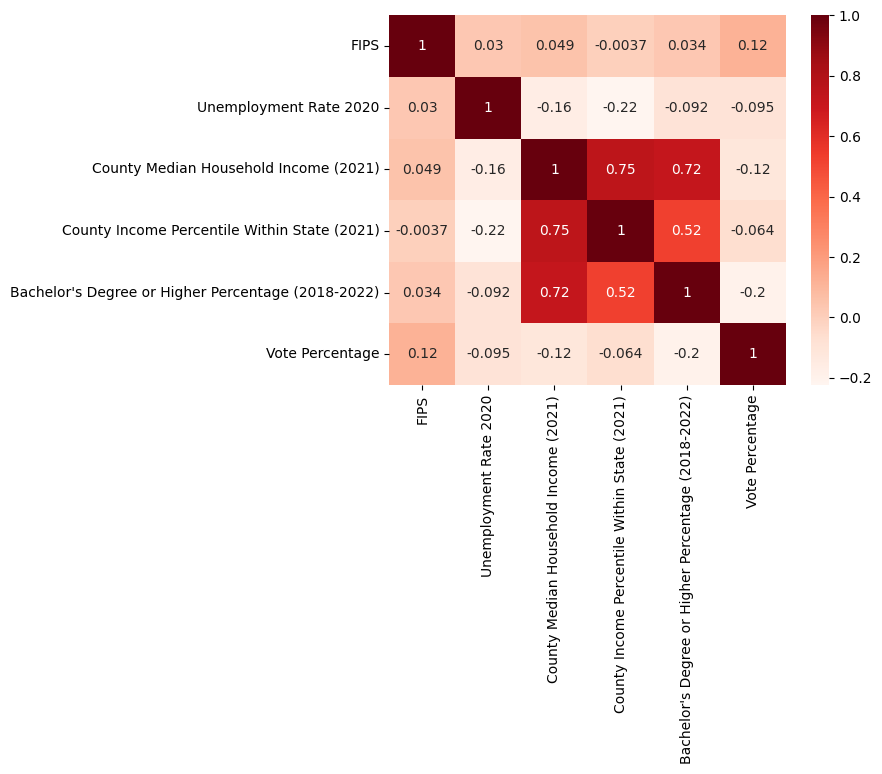

In [96]:
# Create list for the numeric columns
col_list = df.select_dtypes(include=np.number).columns.tolist()
# Create heatmap correlation with red
sns.heatmap(df[col_list].corr(), annot=True, cmap="Reds")

* The correlations greater than 70% are:

  -- County Income Percent. Within State (2021) & County Median Household Inc. (2021) = 75%

  -- Bachelor's Degree or Higher Percent. (2018-2022) & County Median Household Inc. (2021) = 72%



In [100]:
# Create list for the numeric columns
col_list = df.select_dtypes(include=np.number).columns.tolist()

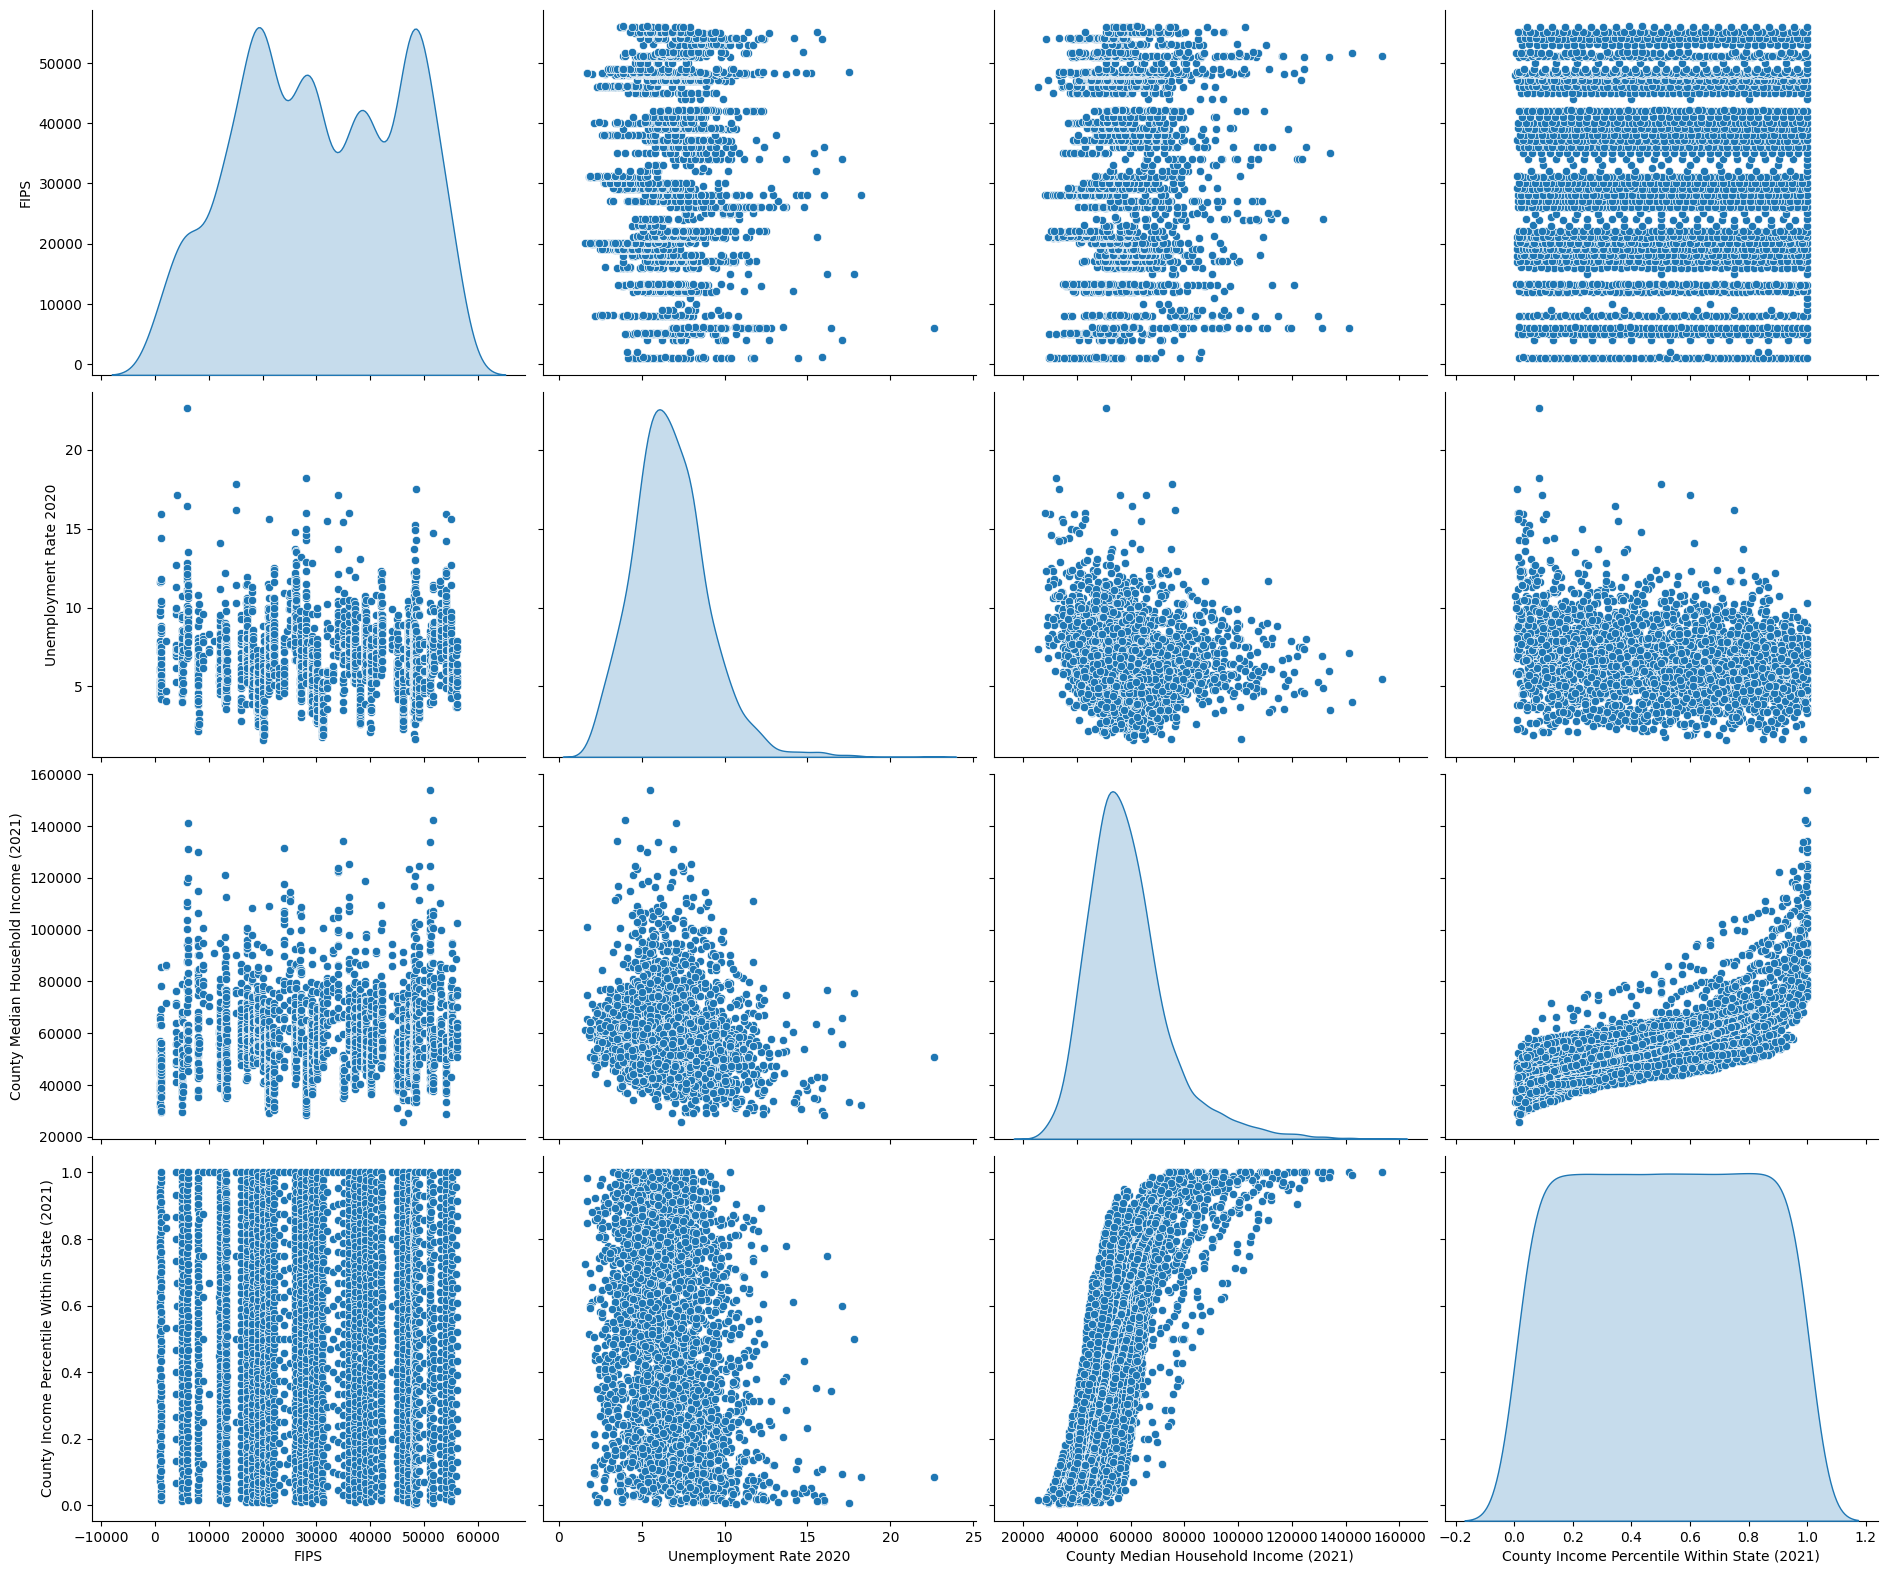

In [101]:
# Create pairplot with density curve on the diag
df = df.iloc[:, 0:7]
sns.pairplot(
    df, diag_kind="kde",
    height=4,
    aspect=1.2
)

plt.show()

* This visually shows County Income Percent. Within State (2021) & County Median Household Inc. (2021) are correlated like per the above heatmap.